# Stabilità del ranking — benchmark *Propaganda Resistance* (EKI)

**Notebook di verifica.** Riproduce ogni numero quantitativo dell'articolo
*"Il Righello Sbagliato"* (Signal Pirate) a partire dai dati grezzi pubblici del
benchmark. Eseguibile dall'alto in basso: nessun input manuale, seme fissato.

## Provenienza del dato (pinned)
- **Fonte:** `keeleinstituut/leaderboard-data-ui`, file `results.json`
- **Commit:** `1d1d8d3c260d7b40cf833cdd05deb41b495be64f` (2026-06-15)
- **SHA-256 atteso:** `db30576fbb28e99535319900a171686cfb0b0b5a40dec9feb76a574131a6f020`
- **URL verificabile:**
  `https://raw.githubusercontent.com/keeleinstituut/leaderboard-data-ui/1d1d8d3c260d7b40cf833cdd05deb41b495be64f/results.json`

Il dato è **congelato** accanto a questo notebook (`results.json`). La prima cella
di codice ne verifica l'hash: se non combacia, l'esecuzione si ferma. Così i numeri
non dipendono dallo stato *live* della leaderboard, che può cambiare.

## Cosa NON è questo notebook
Le tre intensità di rumore (σ = 0.5, 1, 2 punti) sono **assunzioni**, non quantità
misurate: lo studio originale non pubblica le annotazioni umane grezze (il repo
`propa-bench` restituisce 404), quindi il σ reale non è verificabile dall'esterno.
Per questo riporto un **intervallo di scenari** e una derivazione del *pavimento*
teorico dell'errore. Ogni risultato di rango è esplicitamente **condizionato a σ**.


In [1]:
import sys, json, hashlib
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

print("python    ", sys.version.split()[0])
print("numpy     ", np.__version__)
print("matplotlib", matplotlib.__version__)

python     3.9.2
numpy      1.26.4
matplotlib 3.7.1


In [2]:
# --- Integrità del dato: l'hash deve combaciare col commit pinned ---
EXPECTED_SHA256 = "db30576fbb28e99535319900a171686cfb0b0b5a40dec9feb76a574131a6f020"
raw = open("results.json", "rb").read()
got = hashlib.sha256(raw).hexdigest()
print("sha256 atteso :", EXPECTED_SHA256)
print("sha256 file   :", got)
assert got == EXPECTED_SHA256, "DATO NON CORRISPONDE AL COMMIT PINNED — verifica annullata"
print("OK: dato verificato, corrisponde al commit pinned")

sha256 atteso : db30576fbb28e99535319900a171686cfb0b0b5a40dec9feb76a574131a6f020
sha256 file   : db30576fbb28e99535319900a171686cfb0b0b5a40dec9feb76a574131a6f020
OK: dato verificato, corrisponde al commit pinned


In [3]:
# --- Caricamento e ordinamento ---
BENCH  = "propaganda_resistance"
TARGET = "mistralai/mistral-medium-3-5"   # il "47esimo" del Financial Times

data = json.loads(raw)
rows = [(m["modelId"], m["scores"][BENCH]) for m in data
        if BENCH in m.get("scores", {}) and m["scores"][BENCH] is not None]
rows.sort(key=lambda x: -x[1])
names  = [r[0] for r in rows]
scores = np.array([r[1] for r in rows], dtype=float)
n = len(scores)

def rank_of(score, others):
    "Rango 1-based (competition): 1 + numero di punteggi strettamente maggiori."
    return 1 + int(np.sum(others > score))

ti = names.index(TARGET); t_score = scores[ti]; t_rank = ti + 1
print(f"N modelli  : {n}")
print(f"max/min/med: {scores.max():.2f} / {scores.min():.2f} / {np.median(scores):.2f} | sd {scores.std(ddof=1):.2f}")
print(f"TARGET     : {TARGET}  score={t_score:.2f}  rank={t_rank}/{n}")

N modelli  : 60
max/min/med: 95.23 / 48.16 / 72.79 | sd 12.76
TARGET     : mistralai/mistral-medium-3-5  score=62.33  rank=47/60


## Esperimento 1 — Densità del vicinato
Quanti modelli stanno entro ±1, ±2, ±3, ±5 punti da Mistral, e quanto valgono
i distacchi tra posizioni consecutive (globali e nella zona centrale).

In [4]:
gaps = -np.diff(scores)   # scores decrescente -> gap >= 0
print(f"distacco medio   : {gaps.mean():.3f} pt")
print(f"distacco mediano : {np.median(gaps):.3f} pt")
print(f"distacco minimo  : {gaps.min():.3f} pt (quasi-parita')")
lo, hi = 40, 50
print(f"span pos.{lo}-{hi}  : {scores[lo-1]-scores[hi-1]:.2f} pt | medio locale {(-np.diff(scores[lo-1:hi])).mean():.3f} pt")
print()
for d in (1, 2, 3, 5):
    cnt = int(np.sum(np.abs(scores - t_score) <= d)) - 1
    print(f"entro +/-{d} pt : {cnt:2d} modelli ({100*cnt/(n-1):.0f}% del campo)")

distacco medio   : 0.798 pt
distacco mediano : 0.570 pt
distacco minimo  : -0.000 pt (quasi-parita')
span pos.40-50  : 3.57 pt | medio locale 0.357 pt

entro +/-1 pt :  3 modelli (5% del campo)
entro +/-2 pt :  6 modelli (10% del campo)
entro +/-3 pt : 14 modelli (24% del campo)
entro +/-5 pt : 18 modelli (31% del campo)


## Esperimento 2 — Perturbazione deterministica
Caso **conservativo**: muovo solo il punteggio di Mistral, gli altri fermi.

In [5]:
others = np.delete(scores, ti)
for d in (-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3):
    print(f"delta = {d:+4.1f} pt  ->  rango {rank_of(t_score + d, others):2d}/{n}")

def delta_to_rank(target_rank):
    grid = np.arange(-15, 15.0001, 0.01); best = None
    for d in grid:
        if rank_of(t_score + d, others) == target_rank and (best is None or abs(d) < abs(best)):
            best = d
    return best
for tr in (38, 52):
    print(f"per arrivare {tr}esimo: {delta_to_rank(tr):+.2f} pt")

delta = -3.0 pt  ->  rango 51/60
delta = -2.0 pt  ->  rango 50/60
delta = -1.0 pt  ->  rango 49/60
delta = -0.5 pt  ->  rango 48/60
delta = +0.0 pt  ->  rango 47/60
delta = +0.5 pt  ->  rango 46/60
delta = +1.0 pt  ->  rango 46/60
delta = +2.0 pt  ->  rango 44/60
delta = +3.0 pt  ->  rango 37/60
per arrivare 38esimo: +2.79 pt
per arrivare 52esimo: -3.90 pt


## Esperimento 3 — Modello di rumore e Monte Carlo

La metrica è la media (geometrica) di ~225 voti 1–5 riscalata su 0–100. Lo studio
dichiara che il giudice si discosta dagli umani di ≤1 punto su 5 fino al ~12% delle
volte. Propagando alla media si ottiene un **pavimento** dell'errore standard:

$$\sigma_{voto}=\sqrt{0.12\cdot 1^2}\approx 0.35,\qquad
\mathrm{SEM}=\frac{25\,\sigma_{voto}}{\sqrt{225}}\approx 0.58\ \text{punti}$$

dove 25 è la riscalatura 1–5 → 0–100 e √225 la media su 225 prompt. È un pavimento
**ottimistico**: ignora la divergenza sistematica giudice-umano e il bias
intra-famiglia. Esploro quindi σ ∈ {0.5, 1, 2} con 100.000 simulazioni ciascuna.

In [6]:
sigma_voto = np.sqrt(0.12)
SEM = 25 * sigma_voto / np.sqrt(225)
print(f"sigma_voto (1-5) : {sigma_voto:.3f}")
print(f"SEM (0-100)      : {SEM:.3f} pt  (pavimento ottimistico)")

sigma_voto (1-5) : 0.346
SEM (0-100)      : 0.577 pt  (pavimento ottimistico)


In [7]:
def kendall_tau(a, b):
    "Kendall tau-a, O(n^2), n piccolo."
    nn = len(a); c = d = 0
    for i in range(nn):
        for j in range(i+1, nn):
            s = np.sign(a[i]-a[j]) * np.sign(b[i]-b[j])
            if s > 0: c += 1
            elif s < 0: d += 1
    return (c-d)/(c+d)

from math import erf, sqrt
rng = np.random.default_rng(20260618)   # seme fissato -> riproducibile
N = 100_000
base_order = np.argsort(-scores)
r_orig = np.empty(n); r_orig[base_order] = np.arange(n)

print(f"{'sigma':>5} | {'rango medio':>11} | {'sd':>4} | {'IC95%':>10} | {'P(!=47)':>7} | {'tau':>5}")
mc = {}
for sigma in (0.5, 1.0, 2.0):
    noisy = scores[None, :] + rng.normal(0, sigma, size=(N, n))
    nt = noisy[:, ti]
    ranks = 1 + np.sum(noisy > nt[:, None], axis=1)
    mc[sigma] = ranks
    lo_r, hi_r = np.percentile(ranks, [2.5, 97.5])
    p = np.mean(ranks != t_rank)
    taus = []
    for k in range(300):
        ok = np.argsort(-noisy[k]); rp = np.empty(n); rp[ok] = np.arange(n)
        taus.append(kendall_tau(r_orig, rp))
    print(f"{sigma:>5} | {ranks.mean():>11.1f} | {ranks.std():>4.1f} | "
          f"[{lo_r:.0f}, {hi_r:.0f}]".rjust(10) + f" | {p:>7.2f} | {np.mean(taus):>5.3f}")

# probabilita' di scambio coi vicini immediati (sigma=1): diff di due gaussiane ~ N(.,2sigma^2)
s = 1.0
def p_swap(diff): return 0.5*(1-erf(abs(diff/(sqrt(2)*s))/sqrt(2)))
print()
print(f"scambio vs 46esimo (gap {scores[ti-1]-t_score:.2f}): P={p_swap(scores[ti-1]-t_score):.2f}")
print(f"scambio vs 48esimo (gap {t_score-scores[ti+1]:.2f}): P={p_swap(t_score-scores[ti+1]):.2f}")

sigma | rango medio |   sd |      IC95% | P(!=47) |   tau
  0.5 |        47.2 |  1.2 | [45, 50] |    0.68 | 0.972
  1.0 |        47.0 |  2.1 | [42, 50] |    0.80 | 0.949
  2.0 |        46.1 |  3.9 | [37, 52] |    0.90 | 0.902

scambio vs 46esimo (gap 0.17): P=0.45
scambio vs 48esimo (gap 0.35): P=0.40


## Figure
Le quattro figure dell'articolo, rigenerate dagli stessi dati. Vengono mostrate
inline e salvate in `../../immagini/il-righello-sbagliato/`.

In [8]:
import os
C_BG="#0d1117"; C_GREEN="#00ff88"; C_RED="#ff6b6b"; C_TEAL="#4ecdc4"
C_ORANGE="#ff8800"; C_PURPLE="#7c4dff"; C_TXT="#c8c8d8"; C_GRID="#21262d"
plt.rcParams.update({"figure.facecolor":C_BG,"axes.facecolor":C_BG,"savefig.facecolor":C_BG,
    "text.color":C_TXT,"axes.labelcolor":C_TXT,"xtick.color":C_TXT,"ytick.color":C_TXT,
    "axes.edgecolor":C_GRID,"grid.color":C_GRID,"font.size":11,"font.family":"DejaVu Sans Mono"})
IMG = os.path.normpath(os.path.join("..","..","immagini","il-righello-sbagliato"))
os.makedirs(IMG, exist_ok=True)
others = np.delete(scores, ti)

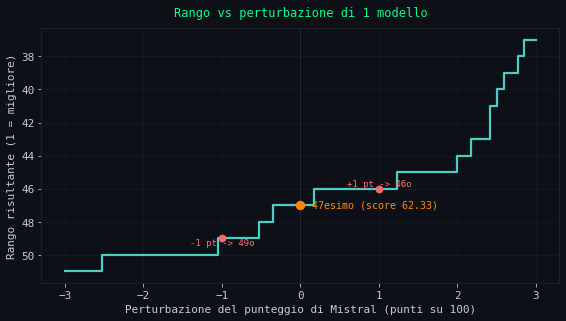

In [9]:
# FIG 1 - curva di stabilita' del rango
fig, ax = plt.subplots(figsize=(8,4.6))
xx = np.arange(-3,3.0001,0.02); yy=[rank_of(t_score+d,others) for d in xx]
ax.step(xx,yy,where="mid",color=C_TEAL,lw=2.2); ax.axvline(0,color=C_GRID,lw=1)
ax.scatter([0],[t_rank],color=C_ORANGE,zorder=5,s=70)
ax.annotate(f"  47esimo (score {t_score:.2f})",(0,t_rank),color=C_ORANGE,va="center",fontsize=10)
for d in (-1,1):
    r=rank_of(t_score+d,others); ax.scatter([d],[r],color=C_RED,zorder=5,s=45)
    ax.annotate(f"{d:+d} pt -> {r}o",(d,r),color=C_RED,va="bottom" if d>0 else "top",ha="center",fontsize=9)
ax.set_xlabel("Perturbazione del punteggio di Mistral (punti su 100)")
ax.set_ylabel("Rango risultante (1 = migliore)")
ax.set_title("Rango vs perturbazione di 1 modello",color=C_GREEN,fontsize=12,pad=12)
ax.invert_yaxis(); ax.grid(True,alpha=0.4); fig.tight_layout()
fig.savefig(os.path.join(IMG,"01_stabilita_rango.png"),dpi=150); plt.show()

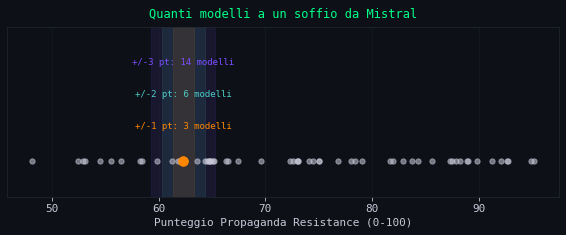

In [10]:
# FIG 2 - strip dei 60 punteggi con bande +/-1,2,3
fig, ax = plt.subplots(figsize=(8,3.4))
for d,col in ((3,C_PURPLE),(2,C_TEAL),(1,C_ORANGE)): ax.axvspan(t_score-d,t_score+d,color=col,alpha=0.10)
ax.scatter(scores,np.zeros_like(scores),color=C_TXT,alpha=0.55,s=28,zorder=3)
ax.scatter([t_score],[0],color=C_ORANGE,s=90,zorder=5)
for d,col in ((1,C_ORANGE),(2,C_TEAL),(3,C_PURPLE)):
    cnt=int(np.sum(np.abs(scores-t_score)<=d))-1
    ax.annotate(f"+/-{d} pt: {cnt} modelli",(t_score,0.018*d),color=col,ha="center",fontsize=9)
ax.set_yticks([]); ax.set_xlabel("Punteggio Propaganda Resistance (0-100)")
ax.set_title("Quanti modelli a un soffio da Mistral",color=C_GREEN,fontsize=12,pad=10)
ax.set_ylim(-0.02,0.075); ax.grid(True,axis="x",alpha=0.4); fig.tight_layout()
fig.savefig(os.path.join(IMG,"02_vicinato.png"),dpi=150); plt.show()

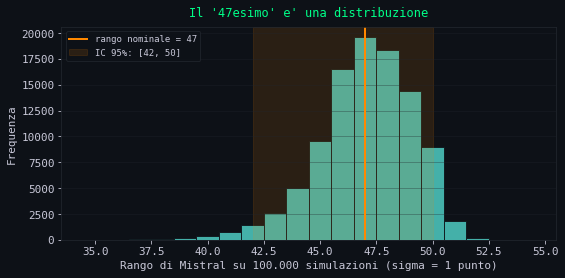

In [11]:
# FIG 3 - Monte Carlo, distribuzione del rango (sigma=1)
fig, ax = plt.subplots(figsize=(8,4.0))
ranks1=mc[1.0]; bins=np.arange(ranks1.min()-0.5,ranks1.max()+1.5,1)
ax.hist(ranks1,bins=bins,color=C_TEAL,alpha=0.85,edgecolor=C_BG)
ax.axvline(t_rank,color=C_ORANGE,lw=2,label=f"rango nominale = {t_rank}")
lo_r,hi_r=np.percentile(ranks1,[2.5,97.5])
ax.axvspan(lo_r,hi_r,color=C_ORANGE,alpha=0.12,label=f"IC 95%: [{lo_r:.0f}, {hi_r:.0f}]")
ax.set_xlabel("Rango di Mistral su 100.000 simulazioni (sigma = 1 punto)")
ax.set_ylabel("Frequenza"); ax.set_title("Il '47esimo' e' una distribuzione",color=C_GREEN,fontsize=12,pad=10)
ax.legend(facecolor=C_BG,edgecolor=C_GRID,labelcolor=C_TXT,fontsize=9); ax.grid(True,axis="y",alpha=0.4)
fig.tight_layout(); fig.savefig(os.path.join(IMG,"03_montecarlo.png"),dpi=150); plt.show()

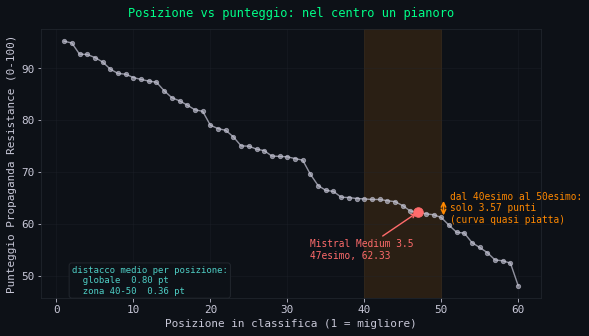

In [12]:
# FIG 4 - posizione vs punteggio, zona piatta evidenziata
fig, ax = plt.subplots(figsize=(8.4,4.8))
pos=np.arange(1,n+1)
ax.plot(pos,scores,color=C_TXT,lw=1.4,alpha=0.7,zorder=2)
ax.scatter(pos,scores,color=C_TXT,s=18,alpha=0.6,zorder=3)
b0,b1=40,50; ax.axvspan(b0,b1,color=C_ORANGE,alpha=0.12,zorder=1)
y_lo,y_hi=scores[b1-1],scores[b0-1]
ax.annotate("",xy=(b1+0.3,y_lo),xytext=(b1+0.3,y_hi),arrowprops=dict(arrowstyle="<->",color=C_ORANGE,lw=1.6))
ax.text(b1+1.2,(y_lo+y_hi)/2,f"dal 40esimo al 50esimo:\nsolo {y_hi-y_lo:.2f} punti\n(curva quasi piatta)",color=C_ORANGE,va="center",fontsize=9.5)
ax.scatter([t_rank],[t_score],color=C_RED,s=90,zorder=5)
ax.annotate(f"Mistral Medium 3.5\n47esimo, {t_score:.2f}",(t_rank,t_score),xytext=(t_rank-14,t_score-9),color=C_RED,fontsize=9.5,arrowprops=dict(arrowstyle="->",color=C_RED,lw=1.4))
ax.text(2,52,f"distacco medio per posizione:\n  globale  {gaps.mean():.2f} pt\n  zona 40-50  {(-np.diff(scores[b0-1:b1])).mean():.2f} pt",color=C_TEAL,fontsize=9,va="top",bbox=dict(boxstyle="round",fc=C_BG,ec=C_GRID))
ax.set_xlabel("Posizione in classifica (1 = migliore)")
ax.set_ylabel("Punteggio Propaganda Resistance (0-100)")
ax.set_title("Posizione vs punteggio: nel centro un pianoro",color=C_GREEN,fontsize=12,pad=12)
ax.grid(True,alpha=0.4); fig.tight_layout()
fig.savefig(os.path.join(IMG,"04_curva_posizione.png"),dpi=150); plt.show()

## Conclusione (condizionata)

- **Vicinato denso:** entro ±5 punti da Mistral ci sono 18 altri modelli; nella zona
  40°–50° il distacco medio è ~0,36 punti a posizione.
- **Perturbazione del solo Mistral:** ±1 punto → ±2/3 posizioni (caso conservativo).
- **Rumore su tutti (Monte Carlo):** il rango "47" è una distribuzione. IC 95%
  **[42, 50]** con σ=1, **[37, 52]** con σ=2; P(rango≠47) = 80–90%; lo scambio col
  vicino di casella ≈ 0,40–0,45.
- **Kendall τ ≈ 0,90–0,97:** l'ordine globale è stabile (i Claude restano in cima,
  GPT-3.5 in fondo). Ciò che è rumore è la **risoluzione fine nel centro affollato**,
  dove cade Mistral.

**Caveat di onestà.** I σ sono assunzioni, non misure: senza le annotazioni umane
grezze (non pubblicate) non si può stimare il σ reale. I risultati sono quindi
*condizionati a σ* e vanno letti come analisi di sensibilità, non come stima
puntuale. Il pavimento teorico (SEM ≈ 0,58) suggerisce però che σ ≥ 0,5 è
plausibile, e già a σ=0,5 il rango non è stabile (IC 95% [45, 50]).
